# 01 Data and calibration
**SYNTHETIC portfolio.** Real inputs: SA macro series. Everything loan-level is simulated with a known default process.
Run `python -m src.pipeline` first.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd, json
from IPython.display import Image, display
pd.set_option('display.width', 200)
O = '../outputs/'
show = lambda f: display(pd.read_csv(O + f).round(4))
show_l = pd.read_csv('../docs/data_lineage.csv'); display(show_l)

,series,source,pulled,transformation,date_pulled
0,repo,built-in SARB MPC decision table,typed in code,effective-month step series; VERIFY vs SARB,2026-10-06
1,prime,derived,-,prime = repo + 3.5pp,2026-10-06
2,cpi_yoy,built-in APPROXIMATE annual CPI,typed in code,interpolated; REPLACE with Stats SA P0141,2026-10-06
3,gdp_yoy,built-in APPROXIMATE annual GDP,typed in code,interpolated; REPLACE with Stats SA P0441,2026-10-06
4,unemployment,built-in APPROXIMATE QLFS rates,typed in code,"quarterly -> monthly, available 2m after quart...",2026-10-06
5,hpi,assumption: HPI y/y = CPI y/y - 1pp,-,compounded monthly; replace with FNB/ABSA/BIS ...,2026-10-06


## Macro inputs

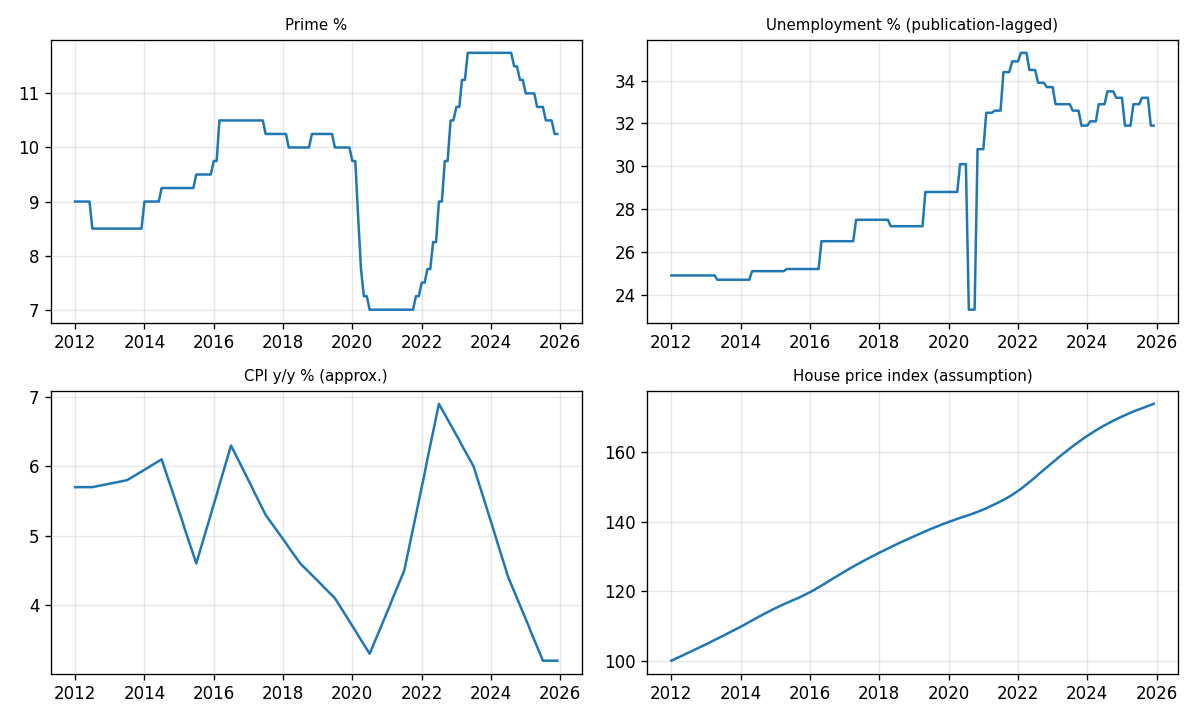

In [2]:
display(Image('../docs/figures/macro.png'))

## Calibration to plausibility targets
Targets (assumptions to verify against SARB / bank disclosures): annual default rate roughly 1-2% in normal years, 3-4% in stress (2020, 2023-24); 30+ dpd share 2-6%; 90+ stock 2-5%; LGD on sold properties 15-30%.

,year,loan_months_performing,new_defaults,arrears_30plus_share,default_stock_share,annual_default_rate
0,2012,10538,1,0.0037,0.0003,0.0011
1,2013,32123,20,0.0071,0.0032,0.0075
2,2014,53504,52,0.0132,0.0080,0.0117
3,2015,75143,50,0.0146,0.0112,0.0080
4,2016,96291,102,0.0161,0.0105,0.0127
5,2017,117002,124,0.0207,0.0159,0.0127
6,2018,138089,163,0.0221,0.0165,0.0142
7,2019,158256,273,0.0275,0.0204,0.0207
8,2020,172719,489,0.0428,0.0320,0.0340
9,2021,191184,142,0.0323,0.0285,0.0089


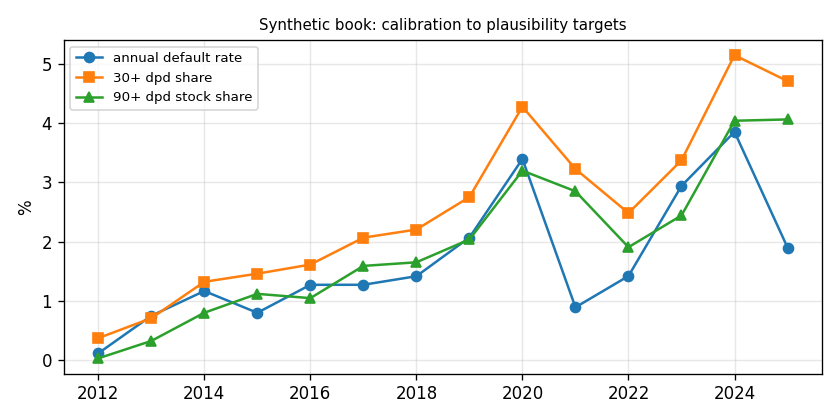

In [3]:
show('calibration_by_year.csv'); display(Image('../docs/figures/calibration_targets.png'))